<a href="https://colab.research.google.com/github/CodeHunterOfficial/ArabovMKDeep/blob/main/IIRSI/Project/Step_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Этап 1. Выбор темы и настройка окружения — подробная методичка

Эта методичка рассчитана на человека, который **никогда** не работал с Python-проектами и не устанавливал ничего сложнее браузера. Каждый шаг расписан так, чтобы его можно было выполнить, не понимая, что происходит. После каждого действия указано, **что вы должны увидеть**, если всё правильно, и **что делать**, если что-то пошло не так.

**Цель этапа:** определить предметную область, установить инструменты, создать репозиторий и подключить внешние сервисы.

**Недель:** 1.

**Что вы получите в конце этапа:**

- установленный Python 3.12;
- установленный редактор VS Code с нужными расширениями;
- установленный Git с настроенным пользователем и SSH-ключом для GitHub;
- аккаунты на GitHub и HuggingFace;
- установленный Poetry для управления зависимостями;
- установленный Ollama с загруженной моделью `qwen2.5:7b`;
- структура папок проекта;
- файлы `pyproject.toml`, `poetry.lock`, `.gitignore`, `.editorconfig`, `.gitattributes`, `.env.example`, `.env`, `README.md`;
- удалённый репозиторий на GitHub с первым коммитом.

**Критерии готовности — чеклист для самопроверки:**

- [ ] Тема выбрана и записана в README.
- [ ] Команда сформирована, роли распределены.
- [ ] Python 3.12 работает (`python --version` показывает `3.12.x`).
- [ ] VS Code открывается, расширения установлены.
- [ ] Git работает, `git config --global --list` показывает ваше имя и email.
- [ ] Аккаунт GitHub создан, SSH-ключ добавлен, `ssh -T git@github.com` отвечает.
- [ ] Аккаунт HuggingFace создан, HF-токен типа Read получен.
- [ ] Poetry работает (`python -m poetry --version` показывает версию 2.x).
- [ ] `virtualenvs.in-project = true` установлено.
- [ ] Ollama установлен и модель загружена (`ollama list` показывает `qwen2.5:7b`).
- [ ] HF-токен сохранён в `.env`.
- [ ] `python -m poetry install` проходит без ошибок.
- [ ] Репозиторий создан, первый коммит запушен.

---

## 1.1. Выбор темы проекта

**Почему это первым шагом:** пока вы не решили, что строите, непонятно, какие данные собирать, какие промпты писать агентам и что вообще тестировать. Тема определяет всё дальнейшее: и структуру базы данных, и вид агентов, и то, какие языки поддерживать.

### Что значит «выбрать тему»

Тема должна быть **конкретной**. Плохие темы:

- «Система перевода» — слишком общо.
- «AI-помощник» — вообще непонятно, что делать.
- «Чат-бот» — что он делает? Кому отвечает?

Хорошие темы:

- «Мультиагентная система перевода медицинских текстов с английского на русский с использованием глоссария и RAG».
- «Система суммаризации юридических документов на русском с мультиагентной проверкой фактов».
- «QA-система по университетским учебникам с гибридным поиском и оценкой уверенности».
- «Генератор сказок для детей на русском с проверкой возрастного рейтинга и морали».
- «Анализатор резюме с сопоставлением с вакансиями и оценкой релевантности».

Чем уже тема — тем проще её защищать. Не бойтесь «урезать»: «система перевода» защитить сложнее, чем «система перевода медицинских текстов».

### Как записать тему

Откройте текстовый файл (пока просто в блокноте) и напишите ответы на три вопроса:

1. **Что делает система?** Одно предложение.
2. **Для кого?** Врач, редактор, студент, юрист, родитель?
3. **Что на входе и что на выходе?** Пример: «на входе — английское предложение, на выходе — русский перевод + оценка качества от 0 до 10».

Пример готовой формулировки:

> **RUNG** — мультиагентная платформа перевода медицинских текстов с английского на русский. На входе — текст или пакет текстов. На выходе — перевод, оценённый Critic'ом, с указанием использованных терминов из глоссария и найденных совпадений в памяти переводов. Система поддерживает активное обучение через HITL: неуверенные переводы попадают в очередь на проверку редактором.

Эту формулировку мы вставим в README в шаге 1.14.

### Формирование команды (2–3 человека)

Если проект командный — распределите роли **сразу**. Иначе на 3-й неделе выяснится, что все пишут агентов, а никто не настраивает Docker.

Примерное распределение:

| Роль | Что делает |
|------|------------|
| Backend-лид | FastAPI, роуты, БД, авторизация, деплой |
| ML/RAG-лид | Агенты, retrieval, эмбеддинги, оценка качества |
| Инфра/QA-лид | Docker, Celery, тесты, документация, UI |

Роли не жёсткие, но у каждого должен быть свой «участок», за который он отвечает на защите.

**Что записать в README:** список участников, их ФИО и зона ответственности.

### Если вы работаете один

Проект можно делать одному. Тогда тема сужается ещё сильнее — оставьте одну языковую пару (например, en→ru), не берите низкоресурсные языки, и ограничьте список агентов тремя (Validator, Critic, Editor).

---

## 1.2. Установка Python 3.12

**Что такое Python и зачем он нам:** Python — это язык программирования, на котором написан весь проект. Без него ничего не запустится. Все наши скрипты, FastAPI, Celery, агенты — это Python-код.

**Почему именно 3.12:** на момент 2026 года версия 3.12 — стабильная и проверенная. Более свежая 3.13 существует, но часть ML-библиотек (`torch`, `transformers`) может не иметь под неё готовых пакетов, и вы потратите день на компиляцию. Версия 3.11 слишком старая. В `Dockerfile` проекта стоит `python:3.12-slim` — локальная версия должна совпадать с контейнером, иначе возможны странные ошибки при переносе кода в Docker.

### Windows — способ 1 (рекомендуемый): Microsoft Store

1. Нажмите **Пуск** (или клавишу Windows), начните вводить «Microsoft Store», откройте приложение.
2. В поиске (верхняя строка) введите `Python 3.12`.
3. В результатах найдите **Python 3.12** от издателя **Python Software Foundation**. Не перепутайте с «Python 3.13» или сторонними пакетами.
4. Нажмите **Получить** (или **Установить**). Дождитесь окончания — обычно 30–60 секунд.
5. После установки **обязательно закройте и заново откройте PowerShell** — иначе команда `python` не подхватится.

**Как открыть PowerShell:** нажмите **Win + X** → в меню выберите **Windows PowerShell** или **Терминал Windows**.

**Проверка:**

```powershell
python --version
```

**Что вы должны увидеть:**

```
Python 3.12.7
```

(или другая цифра после 3.12)

**Если увидели:**

- `Python was not found` — перезапустите PowerShell. Если не помогло — установка не завершилась, повторите.
- `Python 3.11.x` или `Python 3.13.x` — значит, у вас уже стояла другая версия. Не страшно, но нужно убедиться, что при вызове `python` используется именно 3.12. Об этом ниже в 1.6 (Poetry).
- Открылся Microsoft Store с предложением установить Python — значит, `python.exe` нет. Установите из Store и перезапустите консоль.

### Windows — способ 2 (если Microsoft Store недоступен)

1. Откройте [python.org/downloads](https://www.python.org/downloads/).
2. Нажмите жёлтую кнопку **Download Python 3.12.x**.
3. Запустите скачанный `.exe`.
4. **КРИТИЧНО:** на первом экране установщика поставьте галочку **Add python.exe to PATH** (внизу окна). Без этой галочки `python` не будет работать из консоли.
5. Нажмите **Install Now**.
6. После завершения закройте и перезапустите PowerShell.
7. Проверьте: `python --version` → `Python 3.12.x`.

**Если Windows показывает «Windows protected your PC»:**

Нажмите **More info** → **Run anyway**. Это стандартное поведение Defender для самоподписанных установщиков.

### macOS

Откройте Терминал (Cmd+Space → введите «Terminal»), выполните:

```bash
brew install python@3.12
```

**Если `brew` не установлен:** сначала установите Homebrew по инструкции с [brew.sh](https://brew.sh). Это менеджер пакетов для macOS.

**Проверка:** `python3.12 --version` → `Python 3.12.x`.

На macOS команда `python` может указывать на системный Python 2 (устаревший). Всегда используйте `python3.12` или `python3`.

### Linux (Ubuntu 22.04+)

Откройте терминал:

```bash
sudo apt update
sudo apt install python3.12 python3.12-venv python3.12-dev
```

**Проверка:** `python3.12 --version` → `Python 3.12.x`.

### Проверка pip

`pip` — это менеджер пакетов Python. Он понадобится нам для установки Poetry.

```powershell
python -m pip --version
```

**Что вы должны увидеть:**

```
pip 24.x.x from C:\Users\...\site-packages\pip (python 3.12)
```

**Если pip не найден** — выполните:

```powershell
python -m ensurepip --upgrade
```

---

## 1.3. Установка VS Code

**Что это:** VS Code — редактор кода. Это не «программа для программистов», а просто удобный блокнот с подсветкой, автодополнением и встроенным терминалом. Мы будем в нём писать код и запускать команды.

### Установка

1. Откройте [code.visualstudio.com](https://code.visualstudio.com/).
2. Нажмите большую синюю кнопку **Download for Windows** (или для вашей ОС).
3. Запустите скачанный установщик.
4. В окне установщика **обязательно** отметьте галочки:
   - **Add to PATH** (добавить в PATH) — чтобы можно было запускать `code .` из консоли;
   - **Register Code as an editor for supported file types** — чтобы `.py` открывались в VS Code;
   - **Add "Open with Code" action to Windows Explorer file context menu** — правый клик по файлу → «Открыть в Code»;
   - **Add "Open with Code" action to Windows Explorer directory context menu** — правый клик по папке → «Открыть в Code».
5. Нажмите **Далее** → **Установить**.
6. После установки откройте VS Code.

### Что вы увидите при первом запуске

Откроется приветственное окно с кнопками «New File», «Open Folder», «Clone Git Repository». Это нормально. Закройте приветствие (крестик на вкладке Welcome) — мы будем работать с папкой, которую создадим в шаге 1.9.

### Установка расширений

Расширения добавляют в VS Code функции. Нам нужны пять.

**Как открыть панель расширений:** нажмите **Ctrl + Shift + X** (или нажмите иконку из четырёх квадратиков на левой панели).

**Что установить (по одному):**

1. В строке поиска введите `Python` → найдите расширение от **Microsoft** → нажмите **Install**.
2. Введите `Pylance` → от **Microsoft** → **Install**.
3. Введите `Even Better TOML` → от **Tamas Feher** → **Install**.
4. Введите `GitLens` → от **GitKraken** → **Install**.
5. Введите `Docker` → от **Microsoft** → **Install**.

**Зачем они:**

- **Python** — поддержка языка, запуск, отладка, Jupyter.
- **Pylance** — быстрая проверка типов, автодополнение.
- **Even Better TOML** — подсветка и валидация `pyproject.toml`.
- **GitLens** — показывает, кто и когда менял каждую строку.
- **Docker** — управление контейнерами из VS Code (пригодится с этапа 3).

**Проверка:** после установки иконки расширений появятся в списке, кнопка **Install** заменится на **Uninstall** (или шестерёнку).

> **Если пишет «This extension is not compatible»** — обновите VS Code (Help → Check for Updates).



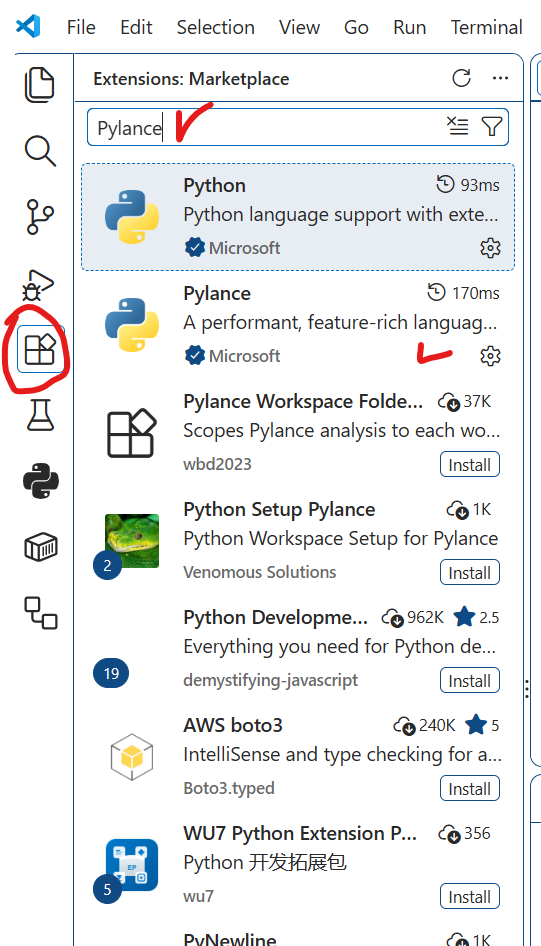



## 1.4. Установка Git

**Что такое Git и зачем:** Git — система контроля версий. Она запоминает, как менялись файлы, позволяет откатываться к старым версиям и синхронизировать работу с другими людьми через GitHub. Без Git нельзя сдать проект — преподаватель попросит ссылку на репозиторий.

### Установка

1. Откройте [git-scm.com/download/win](https://git-scm.com/download/win).
2. Скачайте **64-bit Git for Windows Setup**.
3. Запустите установщик.
4. **Все настройки оставьте по умолчанию**. Можно смело нажимать **Next** до конца. Единственное — на экране **Choosing the default editor used by Git** выберите **Use Visual Studio Code as Git's default editor** (если предложат), чтобы Git открывал VS Code при необходимости писать сообщения коммитов.
5. Нажмите **Install** → дождитесь окончания → **Finish**.

### Проверка

Откройте **новое** окно PowerShell (старое не подхватит PATH) и выполните:

```powershell
git --version
```



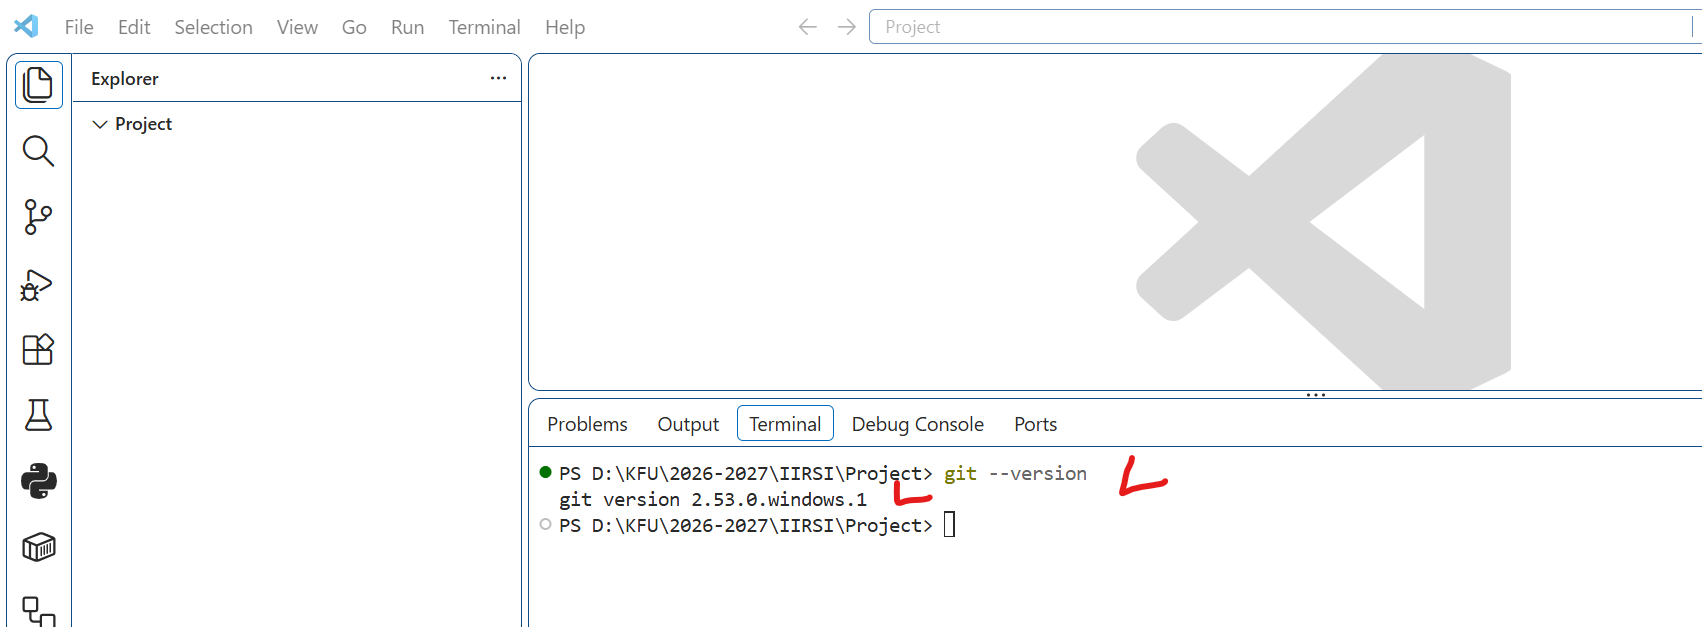


### Настройка пользователя

Git должен знать, кто вы, чтобы подписывать коммиты. Выполните по одной:

```powershell
git config --global user.name "Ваше Имя"
git config --global user.email "ваш@email.com"
git config --global init.defaultBranch main
```

**Замените:**

- `Ваше Имя` — на ваше настоящее имя (например, `Ivan Ivanov`);
- `ваш@email.com` — на email, к которому привязан (или будет привязан) GitHub.

> **Про `init.defaultBranch`:** на Git 2.28 и новее дефолт уже `main`. Если вы уже настраивали Git ранее и не хотите сбивать свои настройки — эту строку можно пропустить.

**Проверка:**

```powershell
git config --global --list
```

**Что вы должны увидеть:**

```
user.name=Ivan Ivanov
user.email=ivan@example.com
init.defaultbranch=main
```

---

## 1.5. Создание аккаунта на GitHub

**Что такое GitHub:** сайт, где хранятся репозитории с кодом. Преподаватель увидит ваш проект именно там.

### Регистрация

1. Откройте [github.com](https://github.com).
2. Нажмите **Sign up** в правом верхнем углу.
3. Введите:
   - **Email** — рабочий, к которому у вас есть доступ;
   - **Password** — минимум 15 символов или 8 символов с цифрой и строчной буквой;
   - **Username** — латиницей, без пробелов, например `ivan-ivanov-rung`.
4. Пройдите капчу, введите код из письма.
5. На предложение «Create your first repository» отвечайте «Skip personalization» — репозиторий создадим вручную в шаге 1.15.

### SSH-ключ (для безопасного пуша)

Есть два способа пушить в GitHub: HTTPS (пароль-токен каждый раз) и SSH (ключ). SSH надёжнее — настроили один раз и забыли.

**Генерация ключа:**

```powershell
ssh-keygen -t ed25519 -C "ваш@email.com"
```

**Программа спросит три раза:**

1. `Enter file in which to save the key (C:\Users\...\.ssh\id_ed25519):` — просто нажмите **Enter**.
2. `Enter passphrase (empty for no passphrase):` — нажмите **Enter** (оставьте пустым).
3. `Enter same passphrase again:` — снова **Enter**.

**Скопируйте ключ в буфер обмена:**

```powershell
cat ~/.ssh/id_ed25519.pub | clip
```

Команда `clip` копирует в буфер обмена Windows. На macOS используйте `pbcopy`, на Linux — `xclip`.

**Добавьте ключ на GitHub:**

1. Откройте [github.com/settings/keys](https://github.com/settings/keys).
2. Нажмите **New SSH key**.
3. Title — любое, например `My laptop`.
4. Key type — **Authentication Key**.
5. В поле **Key** вставьте содержимое буфера (**Ctrl + V**).
6. Нажмите **Add SSH key**.

**Проверка:**

```powershell
ssh -T git@github.com
```

**Что вы должны увидеть:**

```
Hi YOUR-USERNAME! You've successfully authenticated, but GitHub does not provide shell access.
```

Если увидели `The authenticity of host 'github.com' can't be established` — введите `yes` и нажмите Enter.

---

## 1.6. Установка Poetry

**Что такое Poetry:** менеджер зависимостей. Он читает список нужных библиотек из файла `pyproject.toml`, скачивает нужные версии, создаёт виртуальное окружение и следит, чтобы версии не конфликтовали.

**Что такое виртуальное окружение:** отдельная папка с Python и библиотеками, изолированная от системы. Если вы установите `fastapi` внутри окружения, он не попадёт в системный Python. Это позволяет разным проектам иметь разные версии библиотек, не мешая друг другу.

**Почему через `pip`, а не установщиком:** на Windows установщик Poetry кладёт `poetry.exe` в отдельную папку, которая не всегда попадает в PATH. Установка через `pip` позволяет вызывать Poetry командой `python -m poetry`, которая работает всегда — она использует тот Python, который сейчас активен в консоли.

### Установка

```powershell
python -m pip install --user poetry
```


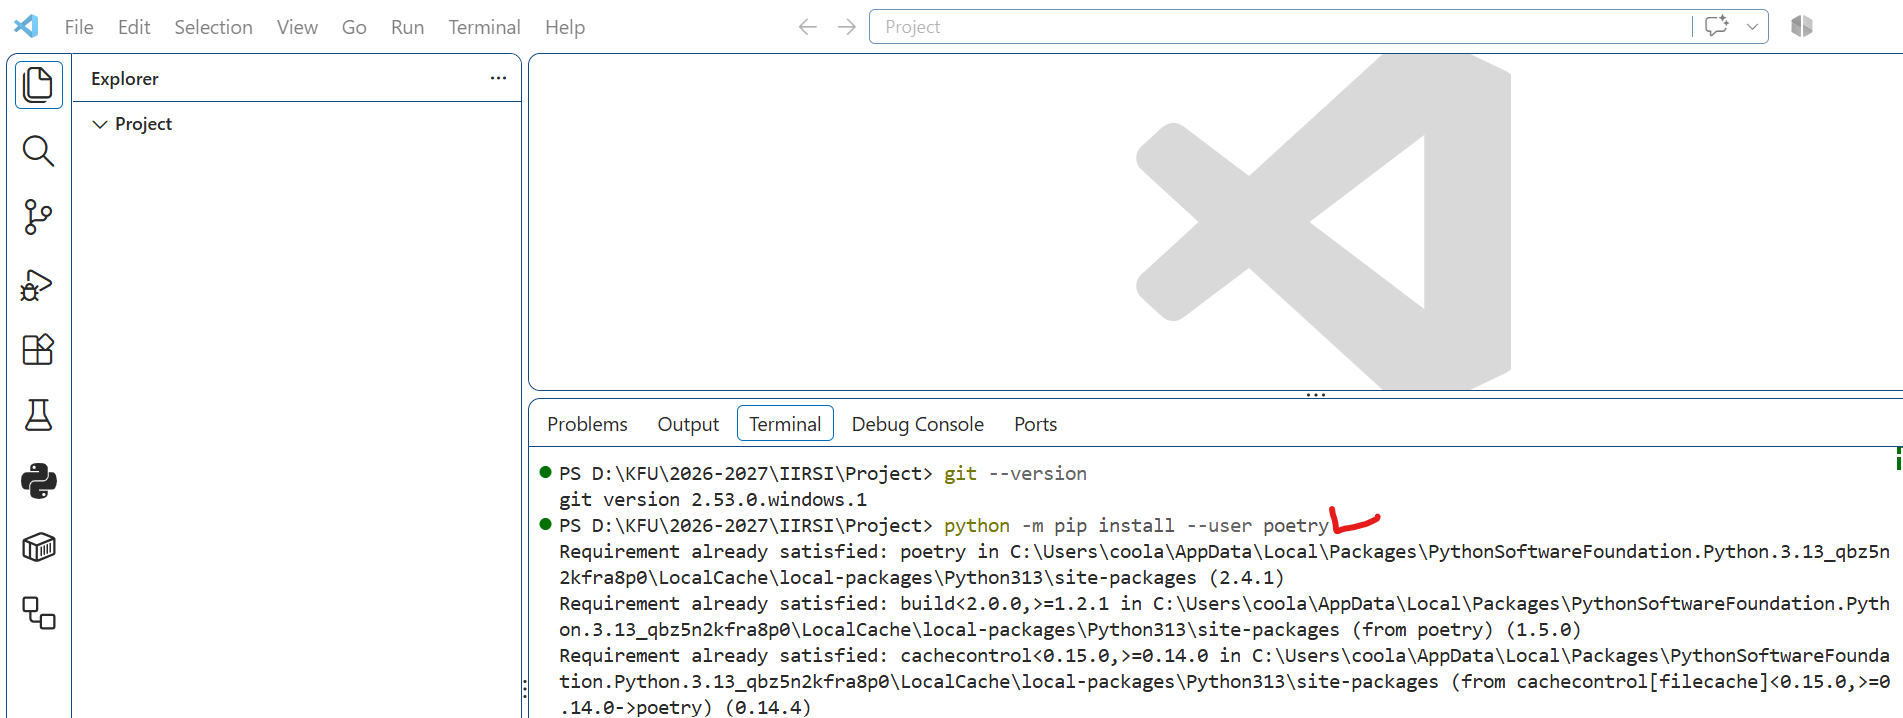


**Что вы должны увидеть в конце:** `Successfully installed poetry-core-... poetry-2.x.x ...` и несколько зависимостей.

**Если пишет `error: externally-managed-environment`:** вы используете Linux с PEP-668. Установите через `pipx`:

```bash
sudo apt install pipx
pipx install poetry
```

**Если пишет `Permission denied`:** добавьте `--user` (уже есть в команде).

### Проверка

```powershell
python -m poetry --version
```

**Что вы должны увидеть:**

```
Poetry (version 2.0.0)
```

(или другая 2.x)

### Настройка

Чтобы Poetry создавал виртуальное окружение **внутри папки проекта** (в подпапке `.venv`), а не в системной папке:

```powershell
python -m poetry config virtualenvs.in-project true
```

**Проверка:**

```powershell
python -m poetry config --list
```

Найдите строку:

```
virtualenvs.in-project = true
```

> **Почему это важно:** VS Code ищет интерпретатор Python в первую очередь в `.venv/` внутри проекта. Если Poetry создаст окружение где-то в `%APPDATA%\pypoetry\`, VS Code его не увидит, и вы будете работать не с тем Python. С настройкой `virtualenvs.in-project=true` всё окажется в ожидаемом месте.

---

## 1.7. Создание аккаунта и токена HuggingFace

**Что такое HuggingFace:** сайт с готовыми ML-моделями. Мы будем скачивать оттуда модели для «второго движка» перевода (HuggingFace Transformers).

### Регистрация

1. Откройте [huggingface.co](https://huggingface.co).
2. Нажмите **Sign Up**.
3. Введите email, пароль, username.
4. Подтвердите email.

### Создание токена доступа

1. Откройте [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens).
2. Нажмите **Create new token**.
3. **Name:** `rung-local`.
4. **Type:** выберите **Read** (этого достаточно для скачивания моделей).
5. Нажмите **Create token**.
6. **Скопируйте значение** — оно начинается с `hf_`. Оно показывается только один раз. Если потеряете — создайте новый.

Сохраните токен пока в текстовый файл. Мы вставим его в `.env` в шаге 1.13.

> **Никогда не публикуйте токен.** Если случайно запушили `.env` в GitHub — немедленно отзовите токен на странице настроек и создайте новый.

---

## 1.8. Установка Ollama

**Что такое Ollama:** программа, которая запускает большие языковые модели (LLM) прямо на вашем компьютере. Именно через неё будут работать агенты Critic и Editor.

### Установка на Windows или macOS

1. Откройте [ollama.com/download](https://ollama.com/download).
2. Нажмите **Download for Windows** (или macOS).
3. Запустите установщик.
4. После установки Ollama запустится как фоновая служба. В системном трее (правый нижний угол Windows) появится иконка ламы.

**Если Windows показывает «Windows protected your PC»:** нажмите **More info** → **Run anyway**. Это ложное срабатывание антивируса для самоподписанных бинарников.

### Установка на Linux

```bash
curl -fsSL https://ollama.com/install.sh | sh
```

### Проверка

Откройте PowerShell:

```powershell
ollama --version
```


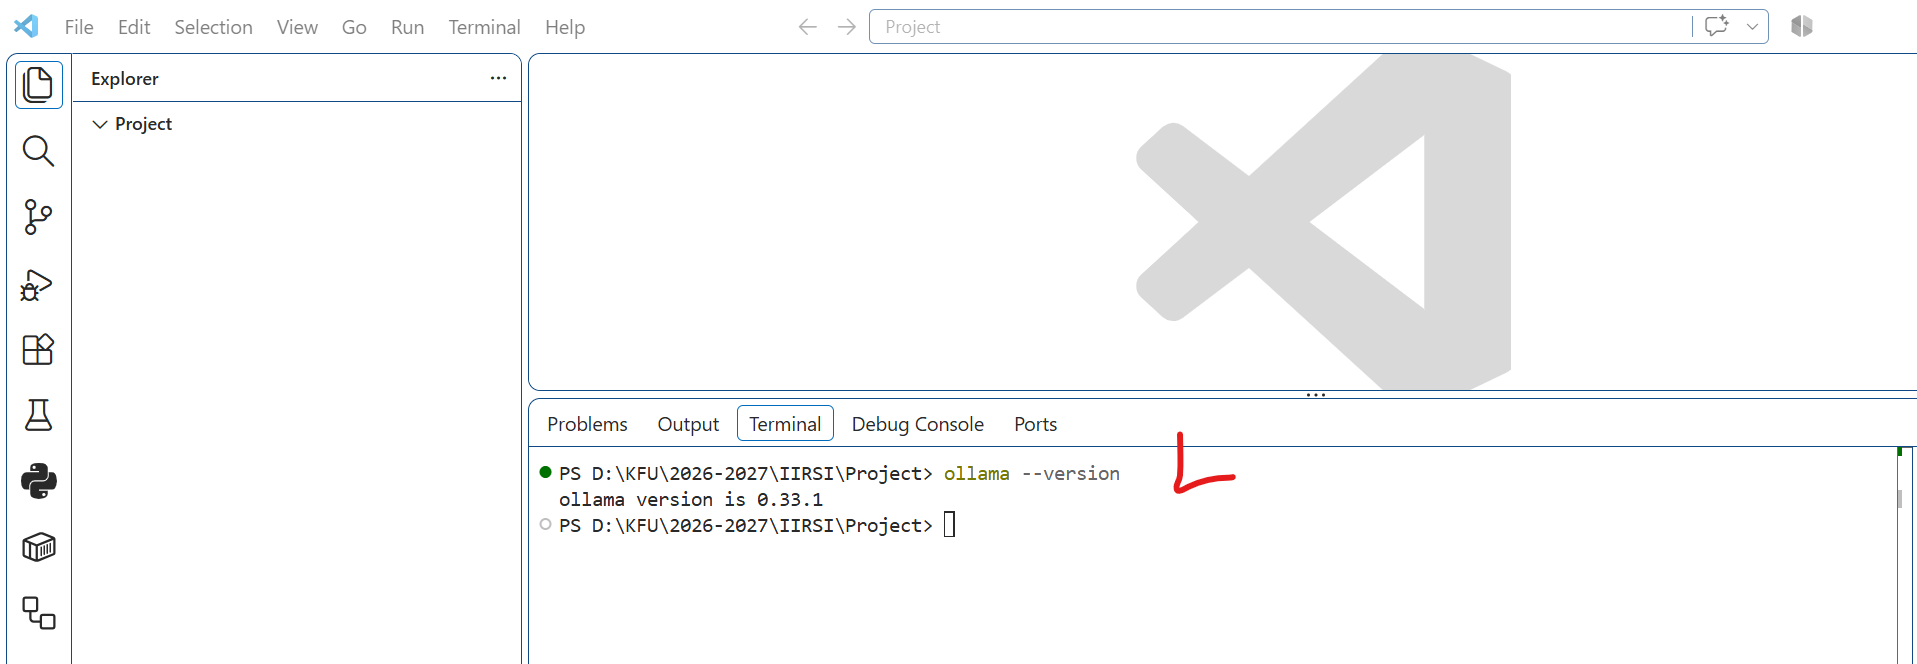


**Проверьте, что сервер отвечает:**

```powershell
curl http://localhost:11434/api/tags
```

**Что вы должны увидеть:** JSON вида `{"models":[]}` (пустой список — это нормально, моделей пока нет).

**Если `curl` не найден** — используйте PowerShell-команду:

```powershell
Invoke-WebRequest -Uri http://localhost:11434/api/tags
```

**Если сервер не отвечает:**

- Windows: проверьте иконку Ollama в трее. Если её нет — запустите Ollama вручную через меню Пуск.
- Если иконка есть, но не отвечает — выполните `ollama serve` в отдельном окне PowerShell. **Не закрывайте окно**, пока работаете — в новом окне выполняйте остальные команды.
- Проверьте, не блокирует ли брандмауэр порт 11434.


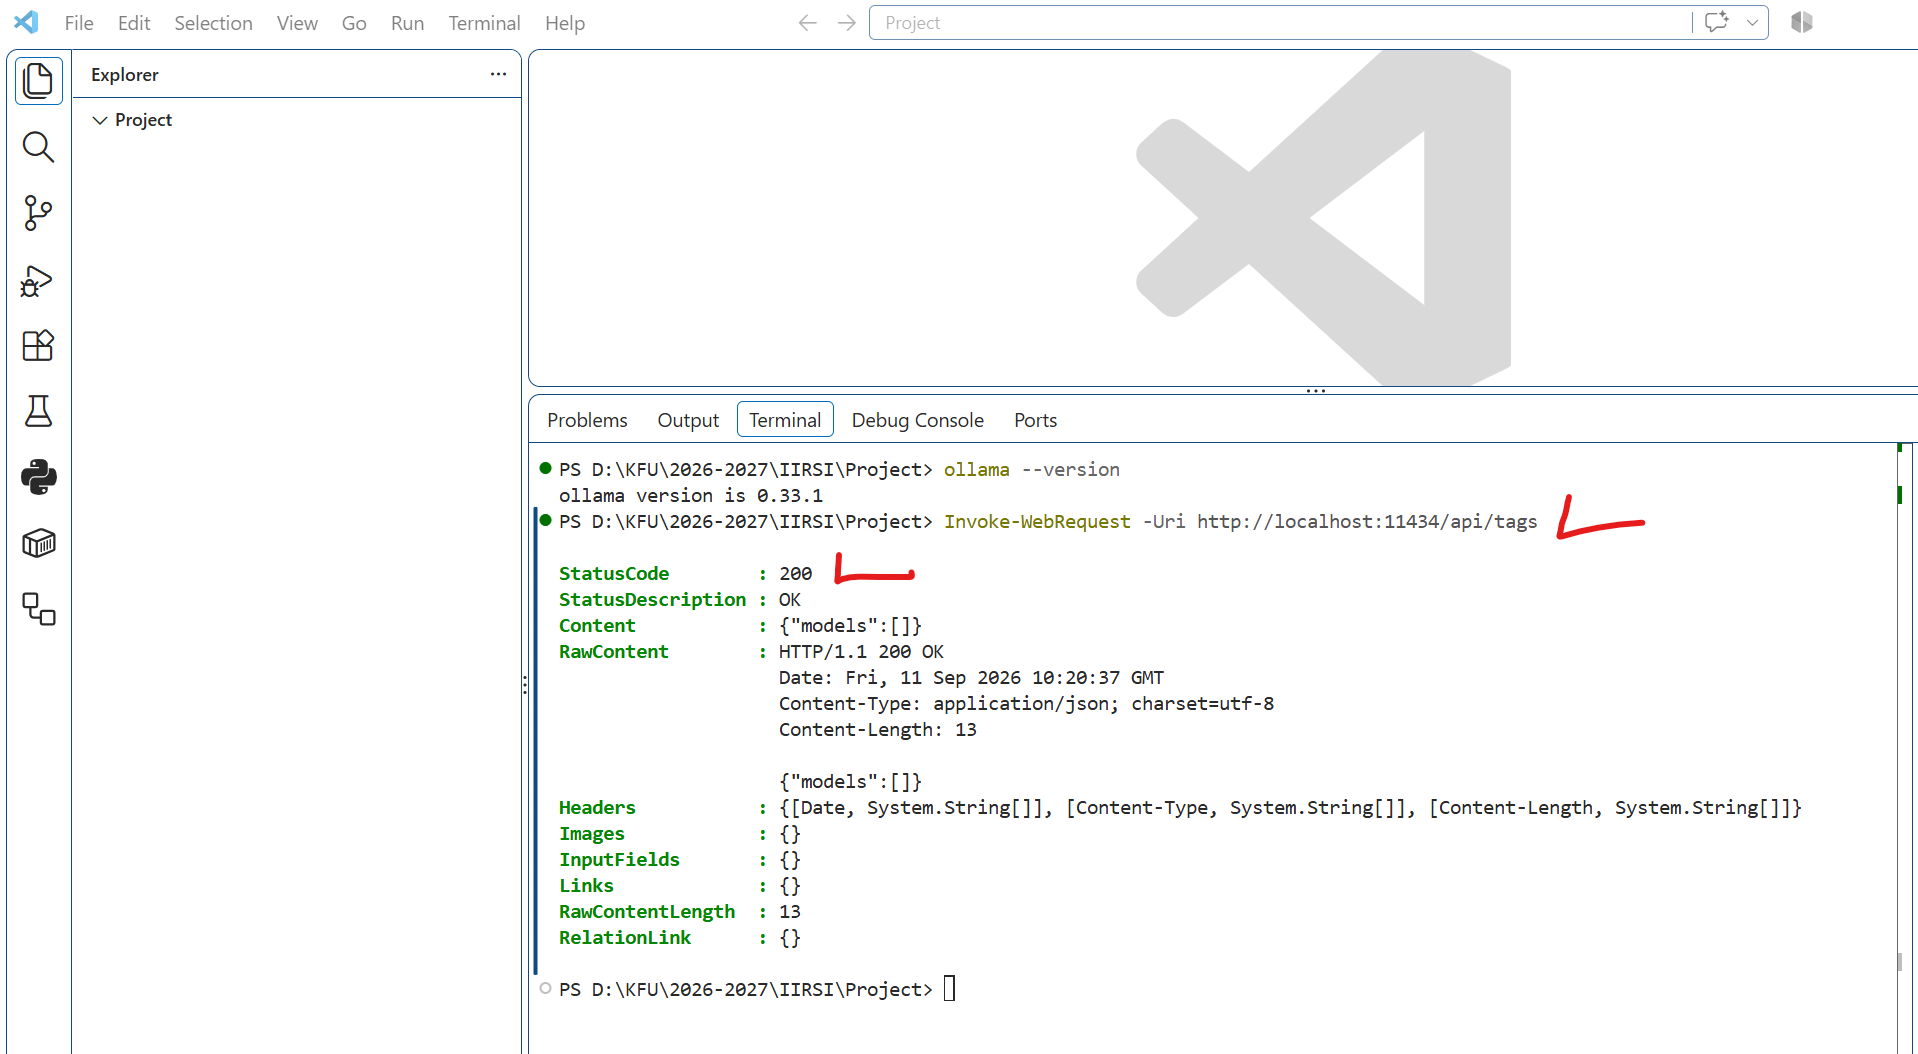


### Загрузка модели

```powershell
ollama pull qwen2.5:7b
```

**Что произойдёт:** начнётся скачивание ~4.7 ГБ. Прогресс отображается в консоли. Займёт 5–15 минут в зависимости от скорости интернета.

**Что вы должны увидеть в конце:**

```
success
```


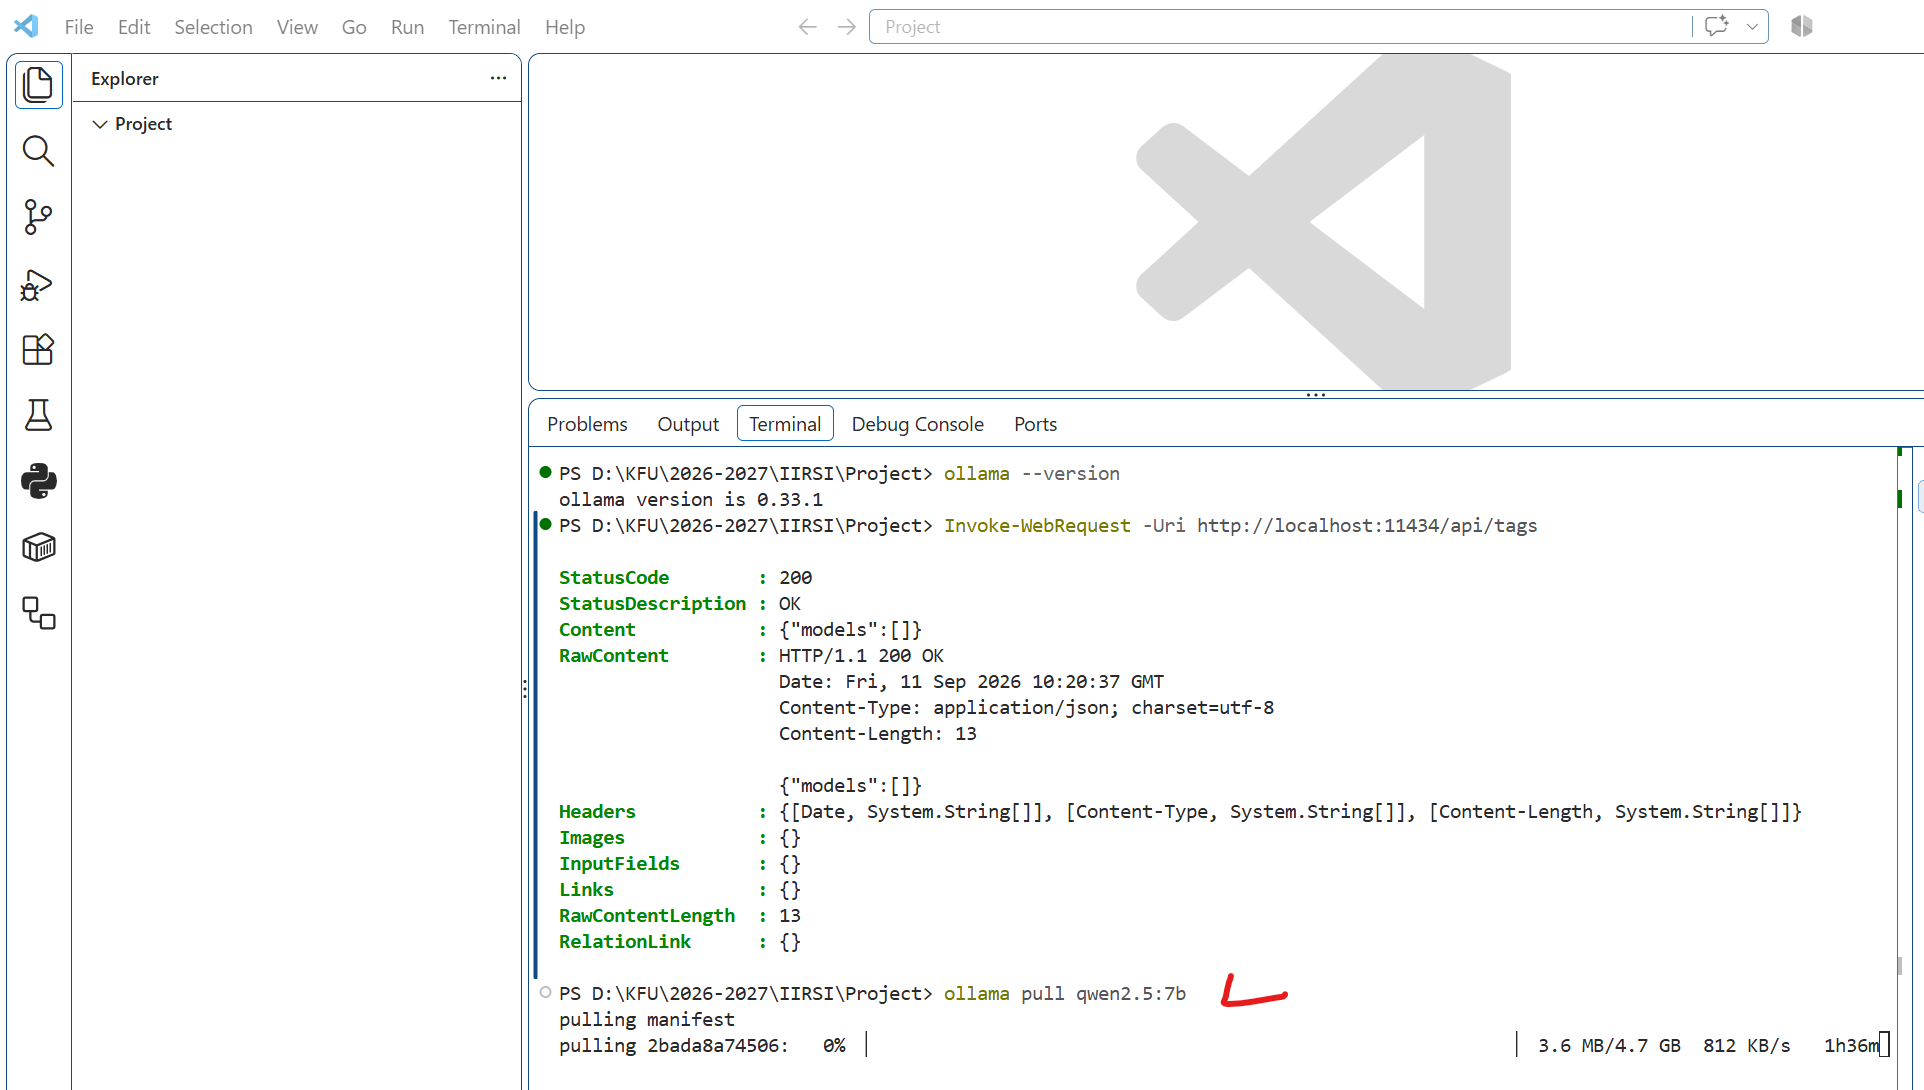


**Проверка, что модель доступна:**

```powershell
ollama list
```

**Что вы должны увидеть:**

```
NAME            ID              SIZE      MODIFIED
qwen2.5:7b      xxxxxxxxxxxx    4.7 GB    X seconds ago
```

**Тест, что модель работает:**

```powershell
ollama run qwen2.5:7b "Переведи на русский: Hello, world!"
```

**Что вы должны увидеть:** модель напишет что-то вроде «Привет, мир!». Первый запуск может занять 10–30 секунд — модель загружается в память.

**Чтобы выйти из интерактивного режима:** введите `/bye` и нажмите Enter.

> **Если у вас меньше 8 ГБ оперативной памяти:** используйте меньшую модель:
> ```powershell
> ollama pull qwen2.5:3b
> ```
> Она весит ~2 ГБ и работает быстрее, но качество перевода чуть ниже. В `.env` тогда напишете `LLM_MODEL=qwen2.5:3b`.
>
> **Если нет GPU:** не проблема. Ollama работает на CPU. Медленно (5–30 секунд на запрос), но для демонстрации в рамках курса этого достаточно. Для ускорения можно уменьшить контекст или взять модель поменьше.

> **Если у вас меньше 16 ГБ RAM и нет GPU:** модель `qwen2.5:7b` может не влезть в память и будет выгружаться/загружаться на каждый запрос. Возьмите `qwen2.5:3b` — она комфортно работает на 8 ГБ RAM.

---

## 1.9. Создание структуры папок

**Зачем:** весь проект будет лежать в одной папке с чётко определённой структурой. Создадим её заранее, чтобы дальше не путаться.

### Windows PowerShell

Откройте PowerShell и выполните **по одной** (не всё сразу — если что-то пойдёт не так, будет видно где):

```powershell
cd D:\
```

(или перейдите в папку, где хотите хранить проект — например, `D:\KFU\2026-2027\IIRSI\Project`)

```powershell
mkdir RUNG
cd RUNG
```

Теперь создайте папки:

```powershell
mkdir backend
mkdir backend\agents
mkdir backend\api
mkdir backend\api\routes
mkdir backend\core
mkdir backend\data
mkdir backend\db
mkdir backend\hitl
mkdir backend\retrieval
mkdir backend\utils
mkdir backend\worker
mkdir tests
mkdir tests\unit
mkdir tests\integration
mkdir infrastructure
mkdir scripts
mkdir data
mkdir data\import
mkdir logs
```


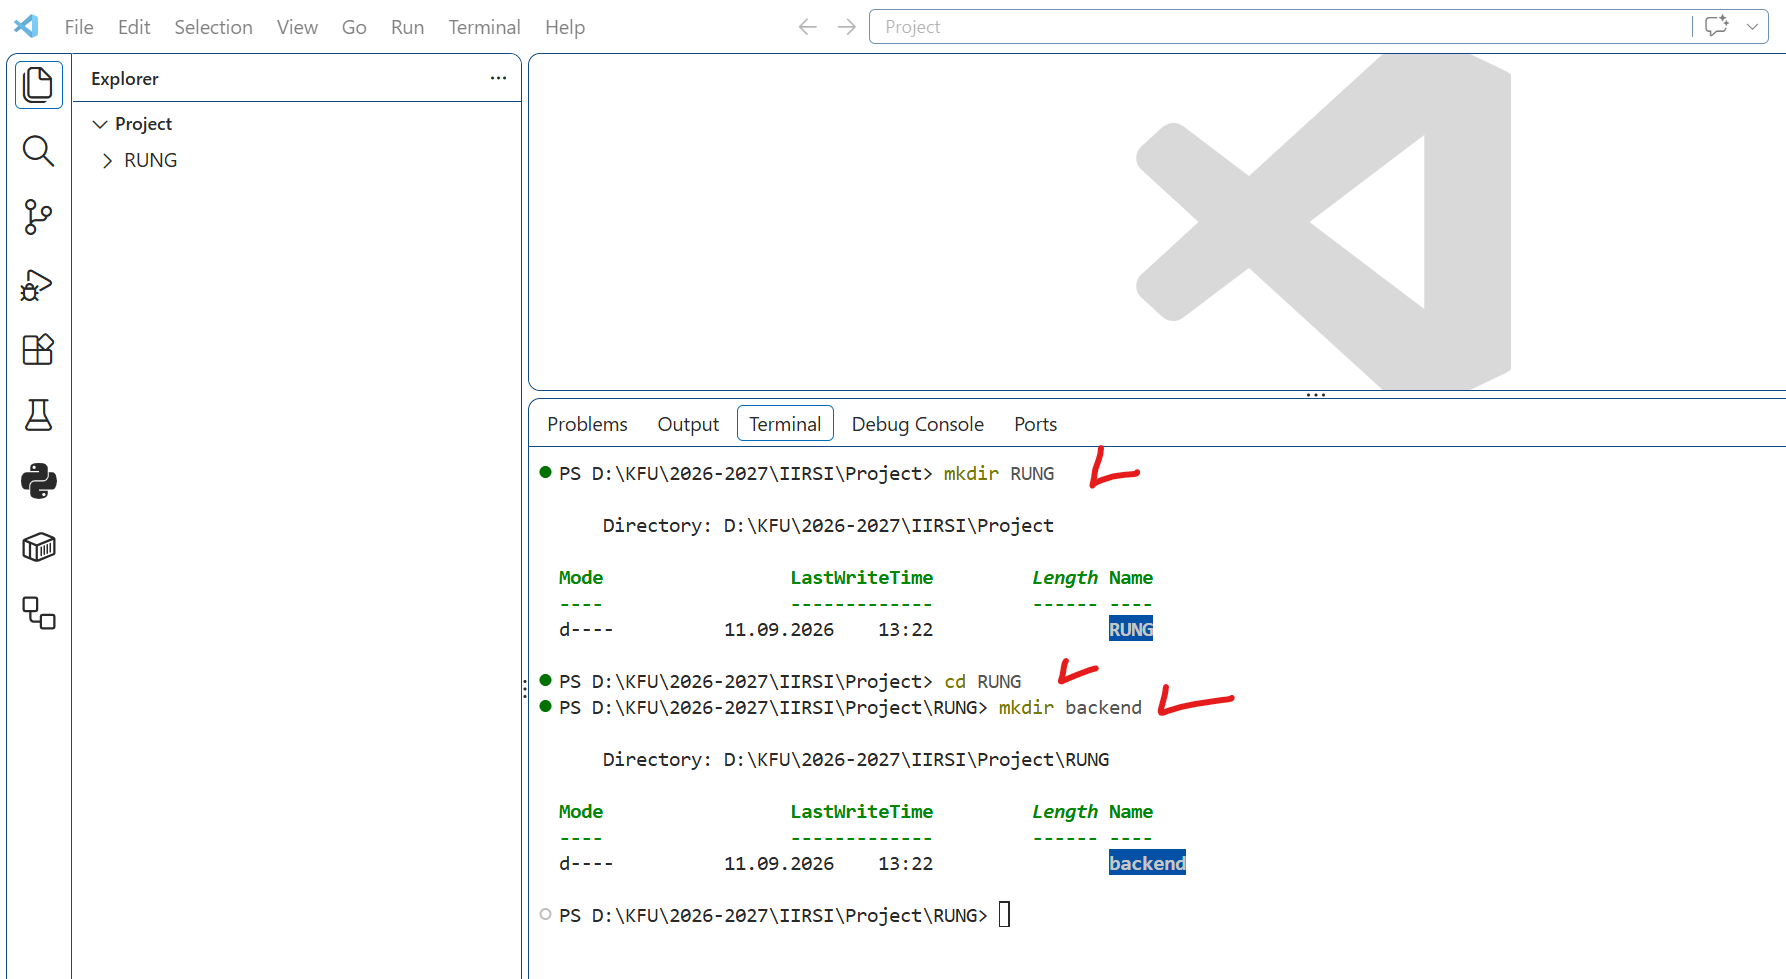


### Создание `.gitkeep` в пустых папках

Git не отслеживает пустые папки. Если папка пустая, после `git clone` у вашего коллеги её не будет. Чтобы этого избежать, в пустые папки кладут файл-заглушку `.gitkeep` (пустой файл).

Создайте `.gitkeep` в:

```powershell
type nul > data\import\.gitkeep
type nul > logs\.gitkeep
```

> **На macOS / Linux:** `touch data/import/.gitkeep logs/.gitkeep`

### Проверка

```powershell
dir
```

**Что вы должны увидеть:**

```
    Directory: D:\RUNG

Mode    LastWriteTime    Length Name
----    -------------    ------ ----
d----   ...             backend
d----   ...             data
d----   ...             infrastructure
d----   ...             logs
d----   ...             scripts
d----   ...             tests
```

Если запутались с путями — можно создать папки вручную через проводник Windows (правый клик → Создать → Папка).

### macOS / Linux

```bash
mkdir -p RUNG/{backend/{agents,api/routes,core,data,db,hitl,retrieval,utils,worker},tests/{unit,integration},infrastructure,scripts,data/import,logs}
cd RUNG
touch data/import/.gitkeep logs/.gitkeep
```

---

## 1.10. Создание `.gitignore`, `.editorconfig`, `.gitattributes`

### 1.10.1 `.gitignore`

**Что это:** файл, в котором перечислены имена файлов и папок, которые Git должен игнорировать. Критично важно, потому что мы **не хотим** заливать в GitHub:

- `.env` — там пароли, токены и секретные ключи;
- `.venv/` — виртуальное окружение, оно у каждого своё и весит сотни мегабайт;
- `__pycache__/` — временные файлы Python;
- `*.db`, `*.sqlite` — локальные базы данных;
- скачанные ML-модели (`*.bin`, `*.safetensors`) — весят гигабайты.

**Создание файла:**

**Способ 1 (через VS Code, рекомендуется):**

1. Откройте VS Code.
2. **File → Open Folder** → выберите созданную папку `RUNG`.
3. В левой панели (Explorer) правый клик по пустому месту → **New File**.
4. Назовите файл `.gitignore` (с точкой в начале, без расширения).
5. Вставьте содержимое ниже.
6. **Ctrl + S** — сохранить.

**Способ 2 (через PowerShell):**

```powershell
notepad .gitignore
```

В блокноте вставьте содержимое, сохраните.

**Содержимое `.gitignore`:**

```
# Python
__pycache__/
*.py[cod]
*.pyo
*.egg-info/
dist/
build/
.pytest_cache/
.mypy_cache/
.ruff_cache/

# Virtual environments
.venv/
venv/
env/
ENV/

# IDE
.vscode/
.idea/
*.swp

# Secrets
.env
.env.*
!.env.example

# Logs
logs/
*.log
!logs/.gitkeep

# Local data (но датасеты в data/import — коммитим)
data/
!data/import/
!data/import/*.csv
!data/import/*.json
!data/import/.gitkeep
*.db
*.sqlite
*.sqlite3

# ML caches / models
.cache/
.huggingface/
*.pt
*.pth
*.bin
*.safetensors

# Jupyter
.ipynb_checkpoints/

# OS
.DS_Store
Thumbs.db
```

**Разбор ключевых строк:**

- `.venv/` — не коммитим виртуальное окружение (его у каждого своё).
- `.env` — не коммитим реальные секреты.
- `!.env.example` — НО коммитим шаблон `.env.example` (в нём нет секретов, только ключи).
- `data/` + `!data/import/` — не коммитим локальные данные, но сохраняем папку с датасетами.
- `!data/import/.gitkeep` — оставляем заглушку, чтобы папка не исчезла.
- `*.pt`, `*.bin` — не коммитим веса моделей.

> **Важно:** `poetry.lock` **не** должен быть в `.gitignore`. Этот файл фиксирует точные версии всех зависимостей и должен быть в репозитории для воспроизводимости.

### 1.10.2 `.editorconfig`

**Что это:** файл, который говорит редакторам кода (VS Code, PyCharm, Sublime) использовать одинаковые отступы, окончания строк и кодировку. Без него у вас на Windows будут CRLF, у коллеги на macOS — LF, и Git будет ругаться на каждый коммит.

**Создайте файл `.editorconfig` в корне:**

```ini
# .editorconfig
root = true

[*]
charset = utf-8
end_of_line = lf
insert_final_newline = true
trim_trailing_whitespace = true
indent_style = space
indent_size = 4

[*.{yml,yaml,json,toml}]
indent_size = 2

[*.md]
trim_trailing_whitespace = false

[Makefile]
indent_style = tab
```

### 1.10.3 `.gitattributes`

**Что это:** файл, который говорит Git, как обрабатывать разные типы файлов. Он заставляет Git хранить все текстовые файлы с LF (даже если вы на Windows), что важно для Docker — Linux не любит CRLF в shell-скриптах.

**Создайте файл `.gitattributes` в корне:**

```
* text=auto eol=lf

*.png binary
*.jpg binary
*.jpeg binary
*.gif binary
*.ico binary
*.pdf binary
*.safetensors binary
*.pt binary
*.bin binary
```

### Инициализация Git

Теперь превратим папку в git-репозиторий:

```powershell
git init -b main
```

**Что вы должны увидеть:**

```
Initialized empty Git repository in D:/RUNG/.git/
```

Проверьте, что `.gitignore` работает:

```powershell
git status
```

**Что вы должны увидеть:**

```
On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
        .editorconfig
        .gitattributes
        .gitignore
        logs/
        data/import/

nothing added to commit but untracked files present (use "git add" to track)
```

Видим `.gitignore`, `.editorconfig`, `.gitattributes`, `data/import/`, `logs/`. Пустые папки `backend`, `tests`, `infrastructure`, `scripts` Git не отслеживает — это нормально.

### Первый коммит

```powershell
git add .gitignore .editorconfig .gitattributes data/import/.gitkeep logs/.gitkeep
git commit -m "chore: add .gitignore, .editorconfig, .gitattributes"
```

**Что вы должны увидеть:**

```
[main (root-commit) abc1234] chore: add .gitignore, .editorconfig, .gitattributes
 5 files changed, 80 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 .editorconfig
 create mode 100644 .gitattributes
 create mode 100644 data/import/.gitkeep
 create mode 100644 logs/.gitkeep
```

---

## 1.11. Инициализация Poetry

Теперь создадим файл `pyproject.toml` — «паспорт» проекта, где указаны имя, версия, автор и зависимости.

**Убедитесь, что вы в папке `RUNG`** (в PowerShell `pwd` должен показать `D:\KFU\2026-2027\IIRSI\Project\RUNG`).

```powershell
python -m poetry init
```

Появится интерактивный диалог. Отвечайте так:

| Вопрос (что показывает) | Что ввести | Пояснение |
|--------------------------|------------|-----------|
| `Package name` | `rung` | Имя проекта, строчными буквами |
| `Version` | `0.1.0` | Начальная версия, стандарт |
| `Description` | `RUNG translation platform` | Кратко, на английском |
| `Author` | `Ваше Имя <email>` | Можно оставить как предложено |
| `License` | **Enter** | Пропускаем |
| `Compatible Python versions` | `^3.12` | **Не** `^3.11`! Должно совпадать с `Dockerfile` |
| `Would you like to define your main dependencies interactively?` | `no` | Зависимости добавим отдельно |
| `Would you like to define your dev dependencies interactively?` | `no` | То же |

Появится подтверждение: `Do you confirm generation? (yes/no) [yes]` — нажмите **Enter**.

**Что вы должны увидеть:** в папке появится файл `pyproject.toml`. Откройте его в VS Code — увидите что-то вроде:

```toml
[tool.poetry]
name = "rung"
version = "0.1.0"
description = "RUNG translation platform"
authors = ["Ваше Имя <email>"]
readme = "README.md"
package-mode = false

[tool.poetry.dependencies]
python = "^3.12"

[build-system]
requires = ["poetry-core"]
build-backend = "poetry.core.masonry.api"
```

> **Что такое `package-mode = false`:** говорит Poetry, что это не библиотека, а приложение. Нам не нужно, чтобы Poetry устанавливал проект как пакет — только управлял зависимостями. По умолчанию `package-mode = true`, но `poetry init` сам ставит `false`, если проект без явного пакета.



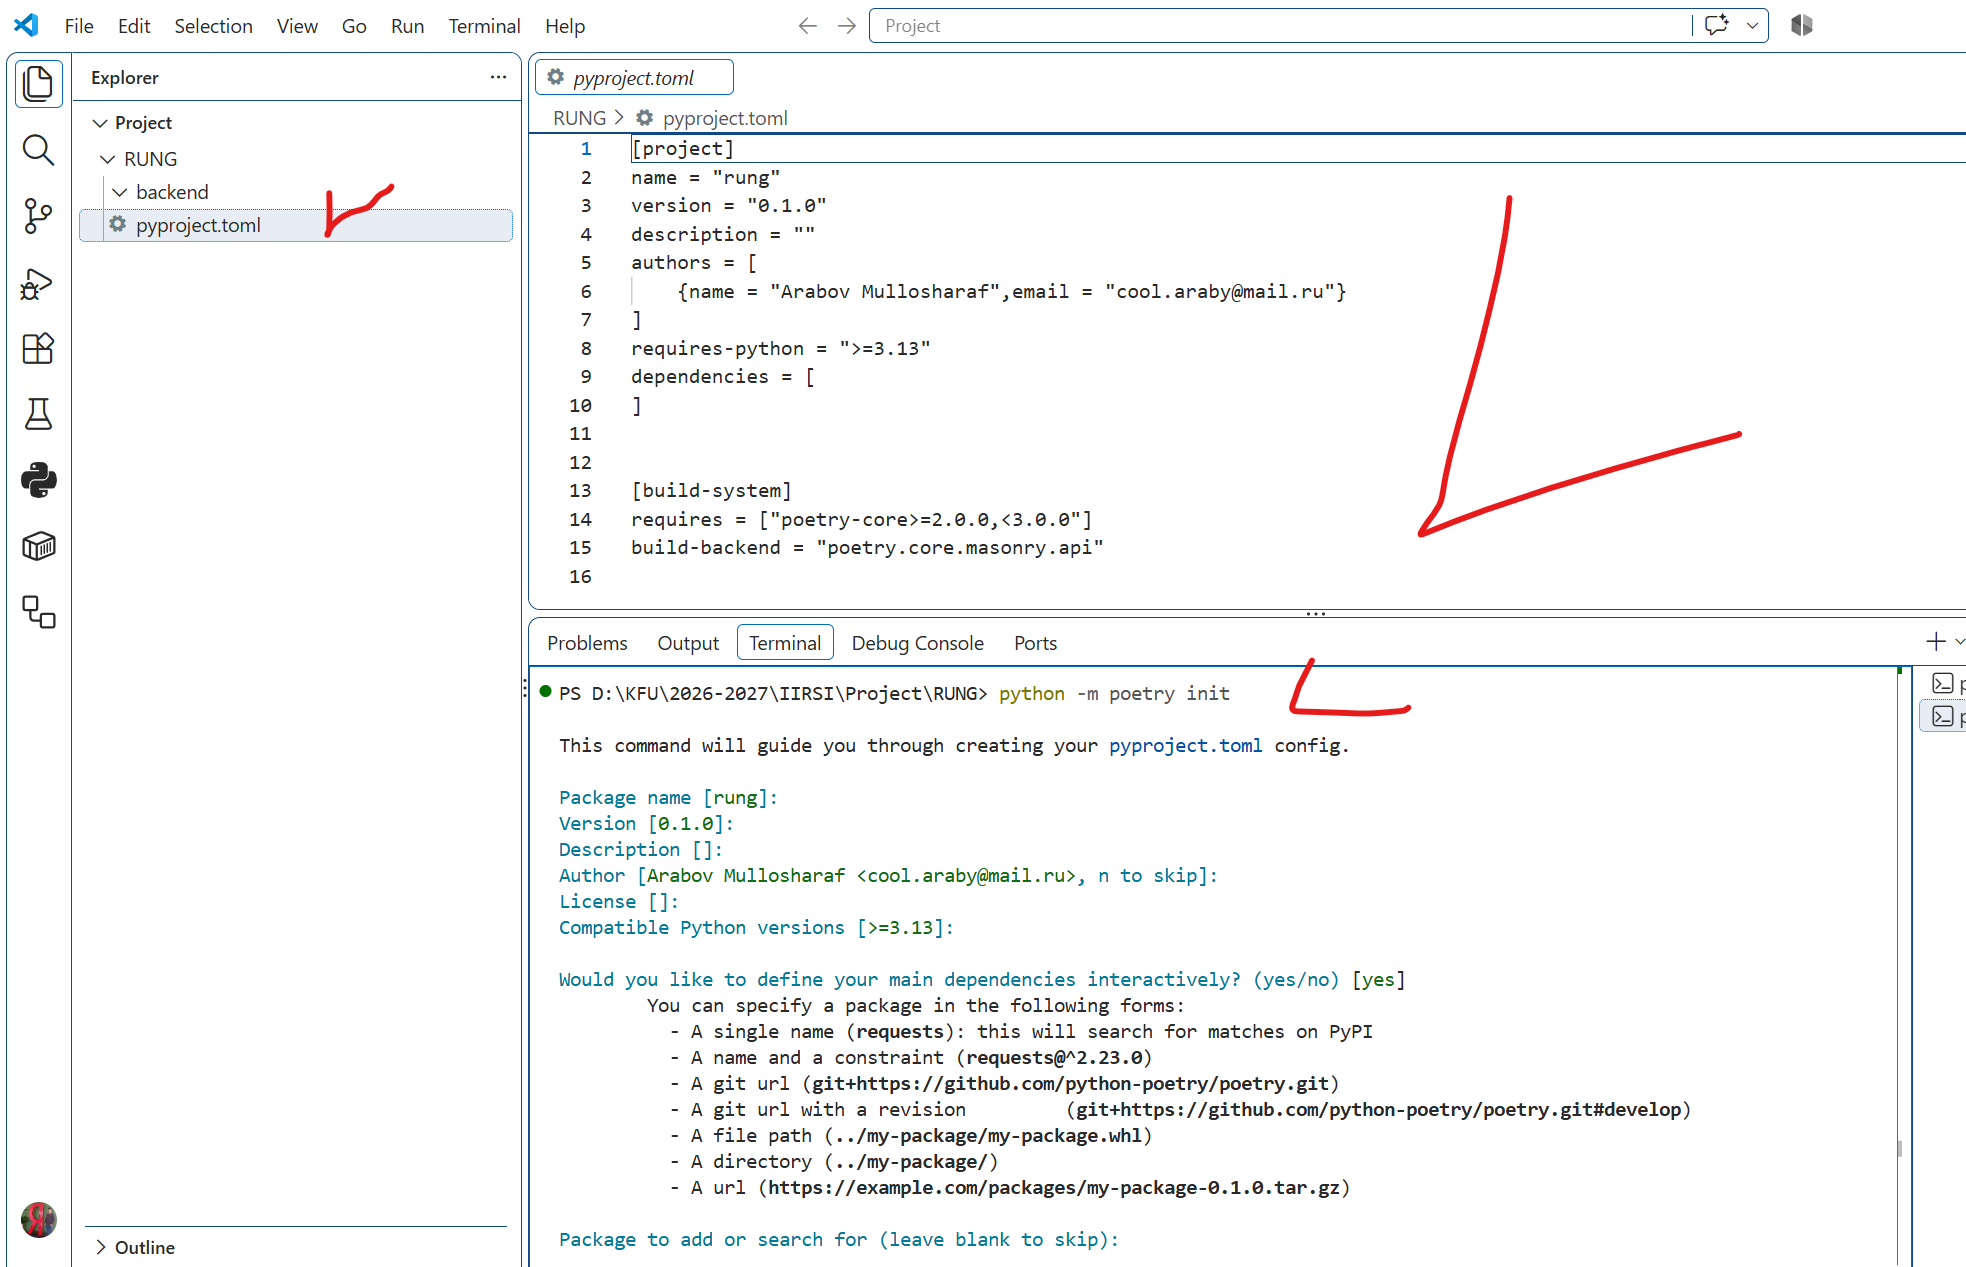



## 1.12. Добавление зависимостей

Теперь наполним `pyproject.toml` списком библиотек. Мы будем добавлять их группами — так легче откатить, если что-то сломается.

### Основные зависимости

Выполняйте по одной команде, ждите завершения каждой:

```powershell
python -m poetry add fastapi "uvicorn[standard]"
python -m poetry add python-dotenv pydantic-settings
python -m poetry add httpx2
python -m poetry add sqlalchemy asyncpg aiosqlite
python -m poetry add python-multipart
python -m poetry add "passlib[bcrypt]" "python-jose[cryptography]" email-validator
python -m poetry add celery redis
python -m poetry add qdrant-client
python -m poetry add sentence-transformers
python -m poetry add transformers torch sentencepiece
python -m poetry add sacrebleu bert-score evaluate
python -m poetry add rank-bm25
python -m poetry add nltk
python -m poetry add python-json-logger
python -m poetry add psycopg2-binary
```

**Что произойдёт:** после каждой команды Poetry выведет список того, что собирается установить, и подождёт подтверждения. Обычно ответ по умолчанию `Y` — нажмите Enter.

**Сколько займёт:** от 5 до 30 минут в зависимости от скорости сети. `torch` — самая тяжёлая зависимость (~2 ГБ), качается дольше всего.

**Что за библиотеки:**

| Пакет | Зачем |
|-------|-------|
| `fastapi` | Web-фреймворк для API |
| `uvicorn[standard]` | ASGI-сервер, на котором работает FastAPI |
| `python-dotenv` | Чтение `.env` файла |
| `pydantic-settings` | Типизированные настройки из env |
| `httpx` | Асинхронный HTTP-клиент (для Ollama, HF API) |
| `sqlalchemy` | ORM для работы с БД |
| `asyncpg` | Асинхронный драйвер PostgreSQL |
| `aiosqlite` | Асинхронный драйвер SQLite (для тестов) |
| `python-multipart` | Парсинг multipart-форм (загрузка CSV) |
| `passlib[bcrypt]` | Хеширование паролей |
| `python-jose[cryptography]` | JWT-токены |
| `email-validator` | Валидация email в Pydantic |
| `celery` | Фоновые задачи |
| `redis` | Брокер сообщений для Celery |
| `qdrant-client` | Клиент векторной БД Qdrant |
| `sentence-transformers` | Модели эмбеддингов |
| `transformers` | HuggingFace-модели |
| `torch` | Нейросети (PyTorch) |
| `sentencepiece` | Токенизация для NLLB и др. |
| `sacrebleu` | Метрика BLEU |
| `bert-score` | Метрика BERTScore |
| `evaluate` | Загрузчик метрик HuggingFace |
| `rank-bm25` | Лексический поиск |
| `nltk` | Инструменты обработки текста |
| `python-json-logger` | Логи в JSON-формате |
| `psycopg2-binary` | Синхронный драйвер Postgres (для Alembic) |


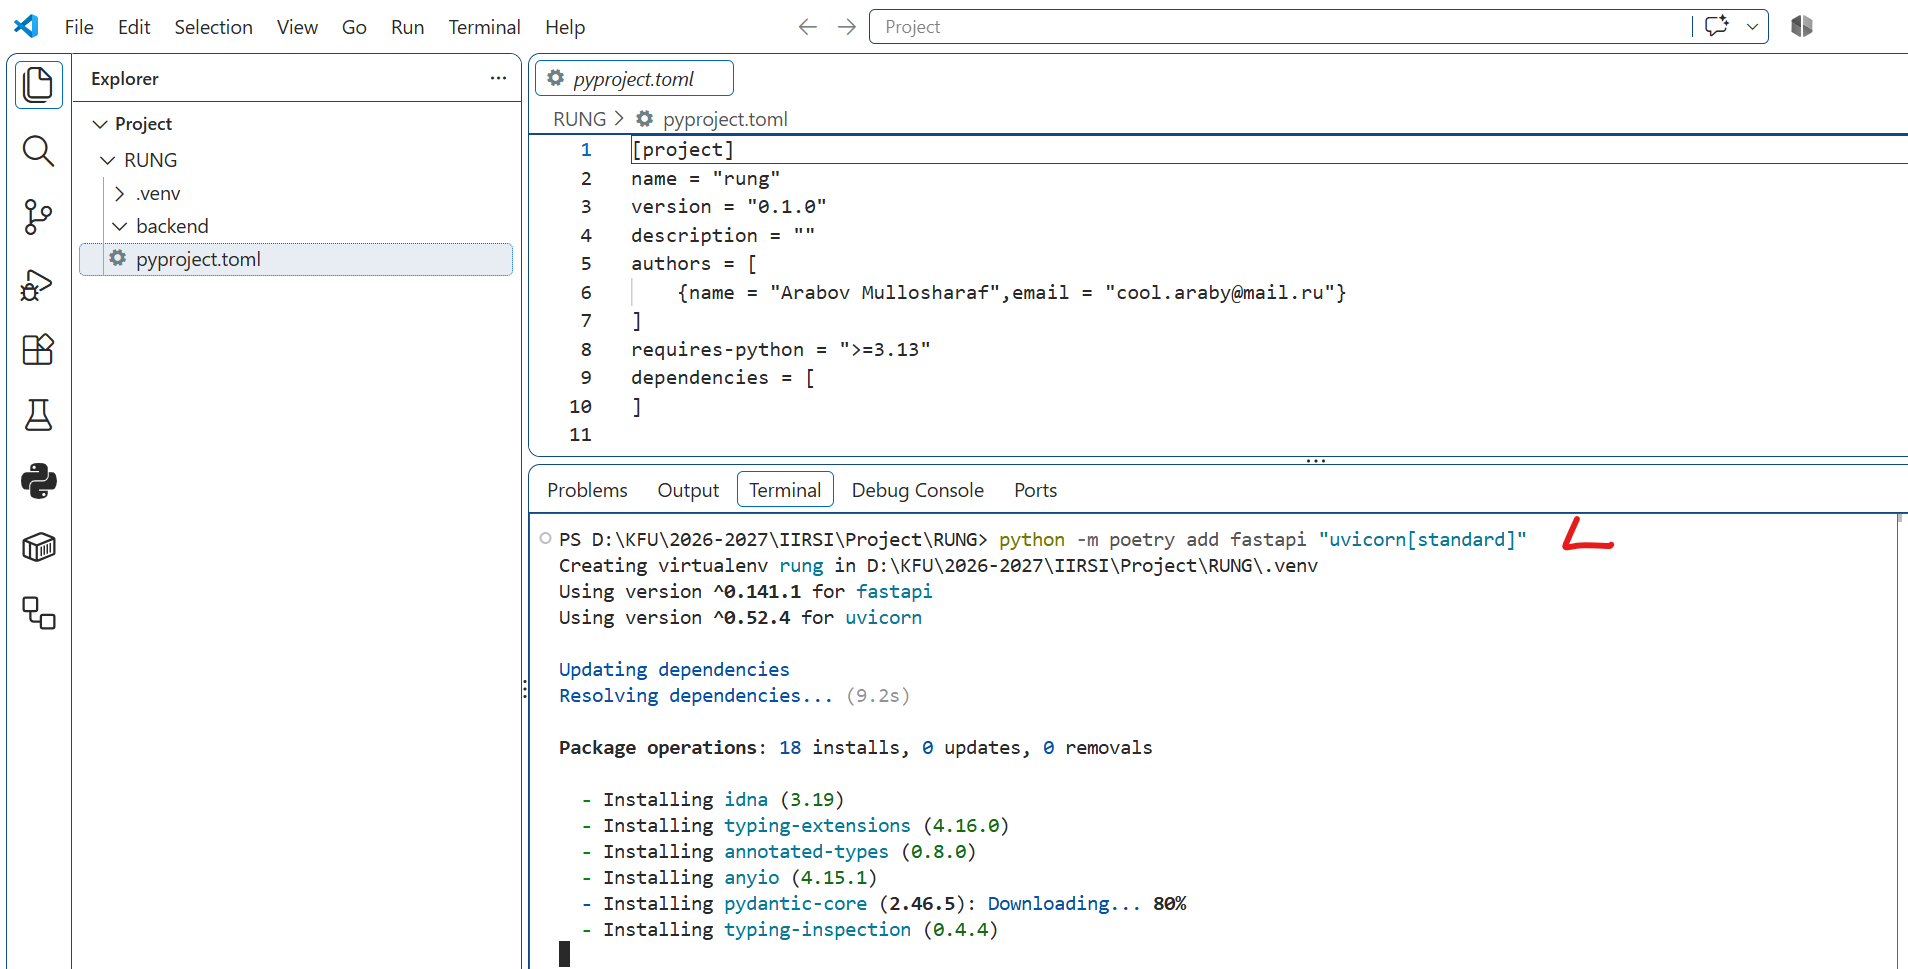


### Если нет GPU — CPU-версия torch

`torch` по умолчанию качает CUDA-версию (для видеокарт NVIDIA), которая весит ~2 ГБ. Если GPU нет, возьмите CPU-версию (~200 МБ):

```powershell
python -m poetry add torch --source pytorch-cpu
```

**Что произойдёт:** Poetry добавит в конец `pyproject.toml` новый source:

```toml
[[tool.poetry.source]]
name = "pytorch-cpu"
url = "https://download.pytorch.org/whl/cpu"
priority = "explicit"
```

### Dev-зависимости

Эти библиотеки нужны только при разработке, в продакшене они не устанавливаются:

```powershell
python -m poetry add --group dev pytest pytest-asyncio pytest-cov pytest-mock
python -m poetry add --group dev black mypy ruff
```

**Что за библиотеки:**

| Пакет | Зачем |
|-------|-------|
| `pytest` | Фреймворк тестирования |
| `pytest-asyncio` | Поддержка async-тестов |
| `pytest-cov` | Покрытие кода тестами |
| `pytest-mock` | Удобные моки |
| `black` | Автоформатирование кода |
| `mypy` | Проверка типов |
| `ruff` | Быстрый линтер |

### Установка

Хотя `poetry add` уже установил всё, что нужно, выполните финальную установку для чистоты:

```powershell
python -m poetry install
```

**Что произойдёт:** Poetry создаст папку `.venv/` внутри проекта и убедится, что все зависимости на месте.

**Что вы должны увидеть в конце:**

```
Installing the current project: rung (0.1.0)
```

**Финальная проверка:**

```powershell
python -m poetry run python --version
```

Должно вывести:

```
Python 3.12.x
```

```powershell
python -m poetry run python -c "import fastapi, sqlalchemy, celery, qdrant_client, torch; print('OK')"
```

Должно вывести:

```
OK
```

**Если увидели `OK`** — всё установлено правильно.

### Типичные ошибки и решения

| Ошибка | Причина | Решение |
|--------|---------|---------|
| `Python version not found` | Poetry не видит 3.12 | `python -m poetry env use python3.12` |
| `torch not found` | Не добавлен источник pytorch-cpu | См. выше |
| `bcrypt` конфликт | Прямая зависимость `bcrypt` конфликтует с `passlib[bcrypt]` | Удалите прямой bcrypt: `python -m poetry remove bcrypt` |
| `psycopg2-binary` не собирается | Нет компилятора C | Установите [Visual C++ Build Tools](https://visualstudio.microsoft.com/visual-cpp-build-tools/) |
| Poetry использует старый Python | В `pyproject.toml` стоит `^3.11` или системный Python 3.11 | `python -m poetry env remove python && python -m poetry env use python3.12 && python -m poetry install` |
| `command not found: poetry` | Забыли `python -m` | Используйте `python -m poetry ...` |
| Долгая установка | Нормально | `torch` — 2 ГБ, ждите |
| `poetry.lock` не создался | Не был запущен `poetry install` | `python -m poetry lock && python -m poetry install` |

---

## 1.13. Файлы `.env.example` и `.env`

**Что такое `.env`:** файл с настройками и секретами (пароли, токены). Он **никогда** не коммитится. Но у каждого разработчика он должен быть. Поэтому мы создаём **два** файла:

- `.env.example` — шаблон без секретов, **коммитится** в Git.
- `.env` — рабочий файл с реальными значениями, **не коммитится**.

### Создание `.env.example`

В корне проекта создайте файл `.env.example` и вставьте:

```dotenv
# Application
DEBUG=true
PROJECT_NAME=RUNG
EVAL_MODE=full
ACTIVE_LEARNING_ENABLED=true

# Translation engine: auto | ollama | huggingface
TRANSLATION_ENGINE=auto
FALLBACK_TO_HF_ON_ERROR=true

# Ollama
OLLAMA_HOST=localhost
OLLAMA_PORT=11434
LLM_MODEL=qwen2.5:7b
CRITIC_MODEL=qwen2.5:7b
EDITOR_MODEL=qwen2.5:7b
VALIDATOR_MODEL=qwen2.5:7b
ENSEMBLE_MODELS=qwen2.5:7b,llama3.1:8b

# Hugging Face (замените your_huggingface_token_here на свой токен hf_...)
HF_TOKEN=your_huggingface_token_here
HF_TRANSLATION_MODEL=facebook/nllb-200-distilled-600M
HF_CRITIC_MODEL=Qwen/Qwen2.5-7B-Instruct
HF_EDITOR_MODEL=Qwen/Qwen2.5-7B-Instruct
HF_VALIDATOR_MODEL=Qwen/Qwen2.5-7B-Instruct

# Services
QDRANT_HOST=localhost
QDRANT_PORT=6333
QDRANT_COLLECTION_NAME=tm_vectors
REDIS_URL=redis://localhost:6379/0

# Database
DATABASE_URL=sqlite+aiosqlite:///./rung.db

# Security (сгенерируйте свой ключ!)
JWT_SECRET_KEY=change_me_to_a_long_random_string
JWT_ALGORITHM=HS256
JWT_EXPIRATION_MINUTES=10080
```

> **Почему placeholder выглядит как `your_huggingface_token_here`, а не `hf_xxxxxx`:** GitHub имеет сканер секретов, который может пометить строку `hf_xxx` как подозрительную. Placeholder без префикса `hf_` безопаснее.

> **Почему в HF-моделях 7B, а не 14B:** модели 14B требуют ~28 ГБ RAM в fp32 или ~9 ГБ в fp16. На типичном студенческом ноутбуке это не заведётся. 7B — компромисс: работает на 16 ГБ RAM. Если у вас GPU с ≥16 GB VRAM, можно заменить на `Qwen/Qwen2.5-14B-Instruct` в `.env`.

### Создание рабочего `.env`

Скопируйте шаблон:

```powershell
Copy-Item .env.example .env
```

Откройте `.env` в VS Code и **отредактируйте два значения**:

1. **`HF_TOKEN`** — вставьте свой токен с HuggingFace (из шага 1.7). Замените `your_huggingface_token_here` на реальное значение, начинающееся с `hf_`.
2. **`JWT_SECRET_KEY`** — сгенерируйте случайную строку:

```powershell
python -c "import secrets; print(secrets.token_urlsafe(64))"
```

Скопируйте результат и вставьте в `.env` вместо `change_me_to_a_long_random_string`.

### Проверка, что `.env` не коммитится

```powershell
git check-ignore -v .env
```

**Что вы должны увидеть:**

```
.gitignore:22:.env    .env
```

Число (22) может быть другим, но главное — что `.env` игнорируется. Если увидели **пустой вывод** — значит `.gitignore` не работает, вернитесь к шагу 1.10.

### Проверка, что `.env.example` коммитится

```powershell
git status
```

В списке untracked files должны быть:

- `.env.example`
- `pyproject.toml`
- `poetry.lock`
- `README.md` (создадим в 1.14)

И **не должно быть** `.env`.

---

## 1.14. Черновик `README.md`

**Зачем README:** это первое, что увидит преподаватель. Оно должно за 30 секунд объяснить, что это за проект и зачем он нужен.

Создайте файл `README.md` в корне:

```markdown
# RUNG — мультиагентная платформа перевода

## Описание
RUNG — система перевода текстов с английского на русский и другие языки.
Использует мультиагентную архитектуру (Validator, Critic, Editor, Supervisor),
гибридный поиск по translation memory (BM25 + Qdrant) и Human-in-the-Loop
для активного обучения.

## Цель проекта
Автоматизировать перевод с качеством, близким к человеческому, за счёт:
- итеративного улучшения перевода агентами;
- использования глоссария и памяти переводов;
- сбора обратной связи от редакторов.

## Стек технологий
- **Backend:** FastAPI, SQLAlchemy (async), Celery, Redis
- **LLM:** Ollama (qwen2.5), HuggingFace Transformers (NLLB, Qwen)
- **RAG:** BM25 (rank-bm25) + Qdrant + RRF-фьюжн
- **Эмбеддинги:** sentence-transformers (paraphrase-multilingual-MiniLM-L12-v2)
- **БД:** PostgreSQL 16, SQLite (для тестов)
- **Инфраструктура:** Docker, Docker Compose, Nginx
- **Оценка качества:** sacrebleu, bert-score, evaluate
- **Тестирование:** pytest, pytest-asyncio, pytest-cov
- **Python:** 3.12

## Команда
- Иванов Иван — backend, агенты, RAG
- Петров Пётр — инфраструктура, Celery, HITL
- Сидоров Сидор — тесты, оценка качества, UI

## Установка и запуск
Будет дополнено на следующих этапах.

## Статус
- [x] Этап 1: выбор темы и настройка окружения
- [ ] Этап 2: каркас приложения
- [ ] Этап 3: база данных
- [ ] Этап 4: аутентификация
- [ ] Этап 5: мультиагентная система
- [ ] Этап 6: данные
- [ ] Этап 7: RAG
- [ ] Этап 8: LLM
- [ ] Этап 9: API
- [ ] Этап 10: HITL
- [ ] Этап 11: Celery
- [ ] Этап 12: Streamlit и Docker
```

**Замените:**

- ФИО в разделе «Команда» на реальные (или удалите, если работаете один);
- описание, если ваша тема отличается;
- язык в описании, если у вас другая пара.

---

## 1.15. Создание репозитория на GitHub и первый push

### Создание пустого репозитория

1. Откройте [github.com/new](https://github.com/new).
2. **Repository name:** `rung`.
3. **Description:** `RUNG translation platform` (необязательно).
4. **Public** или **Private** — на ваше усмотрение (для курсовой лучше Public, чтобы преподаватель мог посмотреть без запроса).
5. **НЕ ставьте** галочки:
   - ❌ Add a README file
   - ❌ Add .gitignore
   - ❌ Choose a license

   Всё это у вас уже есть локально, и если поставить — при первом push возникнет конфликт.
6. Нажмите **Create repository**.

**Что вы должны увидеть:** страницу с подсказками «…or push an existing repository from the command line».

### Связывание локального и удалённого репозиториев

Скопируйте **SSH-ссылку** вида `git@github.com:YOUR-USERNAME/rung.git`. Выполните в PowerShell (в папке проекта):

```powershell
git remote add origin git@github.com:YOUR-USERNAME/rung.git
```

**Замените `YOUR-USERNAME`** на ваш GitHub username.

**Проверка:**

```powershell
git remote -v
```

**Что вы должны увидеть:**

```
origin  git@github.com:YOUR-USERNAME/rung.git (fetch)
origin  git@github.com:YOUR-USERNAME/rung.git (push)
```

### Первый серьёзный коммит

**Сначала проверьте глазами `git status`:**

```powershell
git status
```

**Что вы должны увидеть в untracked files:**

```
.env.example
.editorconfig
.gitattributes
.gitignore
README.md
poetry.lock
pyproject.toml
```

**НЕ должно быть:**

- `.env` (правильно, он игнорируется)
- `.venv/` (правильно)
- `__pycache__/` (правильно)
- `logs/rung_*.log` (правильно)

**Если видите `.env` или `.venv/` — стоп.** Вернитесь к шагу 1.10 и проверьте `.gitignore`.

Если всё в порядке:

```powershell
git add .
git commit -m "chore: initial project setup (Poetry, .gitignore, README, .env.example)"
```

**Что вы должны увидеть:** список добавленных файлов (обычно 7–9).

```powershell
git push -u origin main
```

**Что вы должны увидеть:**

```
Enumerating objects: 10, done.
...
To github.com:YOUR-USERNAME/rung.git
 * [new branch]      main -> main
branch 'main' set up to track 'origin/main'.
```

**Обновите страницу репозитория на GitHub** — файлы появятся в списке.

### Если push не прошёл

| Ошибка | Причина | Решение |
|--------|---------|---------|
| `Permission denied (publickey)` | SSH-ключ не добавлен | Вернитесь к 1.5 |
| `remote origin already exists` | Уже добавляли | `git remote set-url origin git@...` |
| `failed to push some refs` | Репозиторий на GitHub не пустой | Проверьте, что не ставили галочки при создании |
| `Support for password authentication was removed` | Используете HTTPS с паролем | Смените remote на SSH: `git remote set-url origin git@github.com:...` |

---

## 1.16. Финальная проверка этапа

Пройдитесь по чеклисту **по порядку**. Каждая строка — команда и то, что вы должны увидеть.

### 1. Python 3.12

```powershell
python --version
```

→ `Python 3.12.x`

### 2. Git

```powershell
git --version
git config --global --list
```

→ `git version 2.4x.x` и ваши имя/email

### 3. SSH-ключ

```powershell
ssh -T git@github.com
```

→ `Hi YOUR-USERNAME! You've successfully authenticated...`

### 4. Poetry

```powershell
python -m poetry --version
```

→ `Poetry (version 2.x.x)`

### 5. Окружение Python в проекте

```powershell
python -m poetry env info
```

→ строка `Path` указывает **внутрь проекта** (`D:\RUNG\.venv`), `Valid: True`

### 6. Версия Python в окружении

```powershell
python -m poetry run python --version
```

→ `Python 3.12.x`

### 7. Все зависимости

```powershell
python -m poetry run python -c "import fastapi, sqlalchemy, celery, qdrant_client, torch, transformers, sentence_transformers; print('OK')"
```

→ `OK`

### 8. Ollama

```powershell
ollama list
```

→ строка с `qwen2.5:7b`

### 9. Ollama отвечает

```powershell
curl http://localhost:11434/api/tags
```

→ JSON с `models`

### 10. Файлы в проекте

```powershell
dir
```

→ должны быть: `pyproject.toml`, `poetry.lock`, `.gitignore`, `.editorconfig`, `.gitattributes`, `.env.example`, `.env`, `README.md`, папки `backend`, `tests`, `infrastructure`, `scripts`, `data`, `logs`, `.venv`

### 11. `.env` не коммитится

```powershell
git check-ignore -v .env
```

→ строка с `.gitignore`

### 12. Репозиторий

```powershell
git log --oneline
```

→ строка с коммитом `chore: initial project setup...`

```powershell
git remote -v
```

→ `origin  git@github.com:YOUR-USERNAME/rung.git`

### 13. Файлы на GitHub

Откройте `https://github.com/YOUR-USERNAME/rung` в браузере.

**Что вы должны увидеть:** файлы `README.md`, `pyproject.toml`, `poetry.lock`, `.gitignore`, `.editorconfig`, `.gitattributes`, `.env.example`. Файла `.env` **нет** (это правильно).

Если все 13 пунктов прошли — этап 1 завершён.

---

## 1.17. Что делать, если что-то пошло не так

### Python не находится

- **Симптом:** `python: command not found` или `Python was not found`.
- **Причина:** Python не установлен или не добавлен в PATH.
- **Решение:** переустановите Python (1.2), обязательно перезапустите PowerShell.

### Poetry не видит 3.12

- **Симптом:** `python -m poetry install` падает с `Python 3.11 not found` или использует другой Python.
- **Решение:**

```powershell
python -m poetry env remove python
python -m poetry env use python3.12
python -m poetry install
```

### VS Code не видит виртуальное окружение

- **Симптом:** автодополнение не работает, снизу в статус-баре не отображается `.venv`.
- **Решение:**

1. Ctrl+Shift+P → введите `Python: Select Interpreter` → выберите `.venv\Scripts\python.exe`.
2. Если `.venv` нет — выполните `python -m poetry env info --path`. Если путь не внутри проекта — `python -m poetry config virtualenvs.in-project true`, удалите старое окружение и переустановите.

### Ollama не отвечает

- **Симптом:** `curl http://localhost:11434/api/tags` возвращает `connection refused`.
- **Решение:**
  - Windows: откройте Пуск → Ollama. В трее должна появиться иконка ламы.
  - Если не помогает — откройте отдельное окно PowerShell и запустите `ollama serve`. Не закрывайте его.
  - Проверьте, не блокирует ли брандмауэр порт 11434.

### `ollama pull qwen2.5:7b` прервался на середине

- **Симптом:** команда упала с ошибкой сети, `ollama list` показывает модель как `incomplete` или не показывает вовсе.
- **Решение:**
  - Запустите `ollama pull qwen2.5:7b` повторно. Ollama поддерживает докачку с того места, где остановилось.
  - Если не помогает — удалите и скачайте заново: `ollama rm qwen2.5:7b && ollama pull qwen2.5:7b`.

### `ollama pull qwen2.5:7b` не хватает места

- **Симптом:** ошибка `not enough space` или диск переполнен.
- **Решение:**
  - Освободите ~10 ГБ (модель + кэш).
  - Или возьмите меньшую модель: `ollama pull qwen2.5:3b` (~2 ГБ).
  - Не забудьте обновить `.env`: `LLM_MODEL=qwen2.5:3b`.

### HF-токен не работает

- **Симптом:** при попытке скачать модель `401 Unauthorized`.
- **Решение:**
  - Токен должен быть типа **Read**, не Fine-grained.
  - Проверьте, что скопировали целиком (начинается с `hf_`).
  - Проверьте, что модель не `gated` (некоторые модели требуют принятия лицензии на сайте HF).

### `git push` требует пароль

- **Симптом:** Git просит username и password.
- **Причина:** вы используете HTTPS-remote, а GitHub больше не принимает пароли.
- **Решение:** перейдите на SSH:

```powershell
git remote set-url origin git@github.com:YOUR-USERNAME/rung.git
git push -u origin main
```

### `torch` качается вечно

- **Симптом:** установка `torch` занимает больше 30 минут.
- **Причина:** качается CUDA-версия (~2 ГБ).
- **Решение:** прервите (Ctrl+C) и установите CPU-версию:

```powershell
python -m poetry remove torch
python -m poetry add torch --source pytorch-cpu
```

### `poetry.lock` не создался

- **Симптом:** в `git status` нет `poetry.lock`, только `pyproject.toml`.
- **Причина:** не был запущен `poetry install` в конце шага 1.12.
- **Решение:**

```powershell
python -m poetry lock
python -m poetry install
```

### Windows блокирует `ollama.exe` или `poetry.exe`

- **Симптом:** окно «Windows protected your PC».
- **Решение:** нажмите **More info** → **Run anyway**. Это ложное срабатывание для самоподписанных бинарников.

### Порт 11434 занят

- **Симптом:** `ollama serve` пишет `address already in use`.
- **Причина:** Ollama уже запущена как служба, либо порт занят другой программой.
- **Решение:**
  - Проверьте трей — иконка ламы уже может быть там. Если да — сервер уже работает, ничего запускать не надо.
  - Если порт занят другим приложением: `netstat -ano | findstr :11434` → `taskkill /PID <PID> /F`.

---

## Итог этапа 1

К концу этапа у вас есть:

**Инструменты:**

- Python 3.12
- VS Code с расширениями (Python, Pylance, Even Better TOML, GitLens, Docker)
- Git с настроенным пользователем и SSH-ключом
- Poetry 2.x (вызывается как `python -m poetry`)
- Ollama с моделью `qwen2.5:7b`

**Аккаунты:**

- GitHub с созданным репозиторием `rung`
- HuggingFace с токеном доступа типа Read

**Файлы проекта:**

- `pyproject.toml` с `python = "^3.12"` и всеми зависимостями
- `poetry.lock` (закоммичен для воспроизводимости)
- `.gitignore` (не пустит в Git секреты и кэши)
- `.editorconfig` (одинаковые отступы и окончания строк)
- `.gitattributes` (LF для всех текстовых файлов)
- `.env.example` (закоммичен, без секретов)
- `.env` (локально, с HF-токеном и JWT-ключом, не в Git)
- `README.md` с описанием, целью, стеком, командой, статусом
- `data/import/.gitkeep` и `logs/.gitkeep` (заглушки, чтобы папки попали в Git)
- Папки `backend/`, `tests/`, `infrastructure/`, `scripts/`, `data/`, `logs/`

**Репозиторий на GitHub:**

- Создан, первый коммит запушен
- В репозитории только «безопасные» файлы, секретов нет

**Что дальше:** на этапе 2 вы начнёте писать код. Первые файлы:

- `backend/core/config.py` — настройки приложения на Pydantic Settings
- `backend/core/constants.py` — список поддерживаемых языков
- `backend/core/exceptions.py` — базовые исключения
- `backend/utils/logging.py` — цветной вывод, ротация файлов, опция JSON
- `backend/api/main.py` — точка входа FastAPI
- `backend/api/routes/health.py` — эндпоинт `/healthz`
- `run.py` — запуск uvicorn
- Первые тесты: `tests/unit/test_config.py`, `tests/integration/test_health.py`